In [174]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
import odrpack as odr

In [175]:
df = pd.read_excel("p2optica.xlsx", sheet_name="h1input", header=None)

In [176]:
referenceAngle = 54.7

In [177]:
relativeAngle1 = df[3].to_numpy() - referenceAngle
relativeAngle2 = df[4].to_numpy() - referenceAngle
relativeAngle = (relativeAngle1 + relativeAngle2) / 2

In [178]:
difforder = df[0].to_numpy()
wavelengths = df[2].to_numpy()

fittingX = difforder * wavelengths
fittingY = np.sin(relativeAngle*np.pi/180)

errorTheta = np.zeros(len(relativeAngle)) + 0.1
errorThetaAverage = errorTheta*np.sqrt(2)
errorSinTheta = np.abs(np.cos(relativeAngle*np.pi/180)*errorThetaAverage)

In [179]:
colors = ["#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900", "#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900", "#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900", "#000bff", "#00a0ff", "#00d5ff", "#00ff17", "#ff0900"]

In [180]:
def func(x, beta):
    return beta[0] * x + beta[1]

In [181]:
beta0 = [600,0]
#bounds = ([,1500],[-1,1])

sol = odr.odr_fit(func, fittingX, fittingY, beta0, weight_y = 1/(errorSinTheta**2))#, bounds=bounds)

print(sol.beta)

[0.0006069  0.00267852]


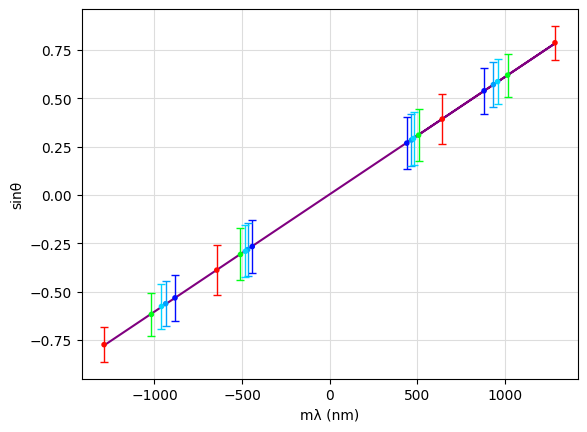

In [199]:
fig, ax = plt.subplots()

ax.scatter(fittingX, fittingY, c=colors, marker=".", zorder = 12)
for i in range(len(fittingX)):
    ax.errorbar(fittingX[i], fittingY[i], yerr = errorSinTheta[i], fmt = "none",  elinewidth=1, ecolor=colors[i], capsize = 3, zorder = 10)
ax.plot(fittingX, func(fittingX, sol.beta), color="purple", zorder = 2)

ax.grid(c = "#dddddd", zorder = 0)
ax.set_xlabel("mλ (nm)")
ax.set_ylabel("sinθ")

plt.show()